# Representative Subset Selection via K-Medoids

Select X objects per IFC type that best represent the full dataset.

## Method

**K-Medoids:** For each IFC type, cluster its objects into X groups, then pick 
the most central (medoid) object from each group. Dense regions get more 
representatives — the subset is a miniature version of the full class.

## Why K-Medoids over FPS?

| Method | Picks | Result |
|--------|-------|--------|
| FPS (diversity) | Extremes/outliers | Over-represents rare geometry |
| **K-Medoids (representative)** | **Typical objects** | **Miniature version of full data** |

## Output

A CSV with GlobalIds of selected objects → loadable in the 3D OBJ viewer.

## 1. Setup

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cdist, pdist
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete")

Setup complete


In [37]:
# Load data
FEATURES_PATH = Path('../../processed_data/features/train_enhanced_features.parquet')
df = pd.read_parquet(FEATURES_PATH)
print(f"Loaded {len(df):,} samples")
print(f"IFC Types: {df['IfcType'].nunique()}")
print(f"\nSmallest classes:")
print(df['IfcType'].value_counts().tail(5))

Loaded 128,883 samples
IFC Types: 24

Smallest classes:
IfcType
IfcDistributionFlowElement    124
IfcCovering                   114
IfcRoof                        79
IfcStair                       75
IfcCurtainWall                 42
Name: count, dtype: int64


## 2. Configuration

In [38]:
# How many objects per IFC type
X_PER_CLASS = 100

# Features to use for diversity measurement
FEATURE_COLS = [
    'Length', 'CrossSectionArea', 'Volume', 'NumVertices',
    'aspect_ratio_1', 'aspect_ratio_2', 'pca_planarity',
    'face_area_cv', 'hull_vertex_ratio'
]

print(f"Selecting {X_PER_CLASS} objects per IFC type")
print(f"Using {len(FEATURE_COLS)} features for diversity")
print(f"Expected total: {X_PER_CLASS} × {df['IfcType'].nunique()} = {X_PER_CLASS * df['IfcType'].nunique()} objects")

# Check which classes have fewer than X
small_classes = df['IfcType'].value_counts()
small_classes = small_classes[small_classes < X_PER_CLASS]
if len(small_classes) > 0:
    print(f"\nWARNING: {len(small_classes)} classes have fewer than {X_PER_CLASS} samples:")
    for ifc_type, count in small_classes.items():
        print(f"  {ifc_type}: {count} (will take all)")
else:
    print(f"\nAll classes have >= {X_PER_CLASS} samples.")

Selecting 100 objects per IFC type
Using 9 features for diversity
Expected total: 100 × 24 = 2400 objects

  IfcRoof: 79 (will take all)
  IfcStair: 75 (will take all)
  IfcCurtainWall: 42 (will take all)


## 3. K-Medoids Selection

For each IFC type:
1. Cluster into X groups using KMeans
2. Pick the real data point closest to each centroid (= medoid)
3. Dense sub-populations get more representatives automatically

**Result:** A miniature version of each class — typical objects, not outliers.

In [39]:
def kmedoids_selection(X: np.ndarray, n_select: int, random_state: int = 42) -> np.ndarray:
    """
    Select n_select representative points from X using KMeans + medoid picking.
    
    Algorithm:
        1. Run KMeans with n_select clusters
        2. For each cluster, pick the real data point closest to the centroid
    
    Dense regions produce more clusters → more representatives.
    
    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Scaled feature matrix
    n_select : int
        Number of points to select
    
    Returns
    -------
    np.ndarray of selected indices
    """
    n = len(X)
    if n_select >= n:
        return np.arange(n)
    
    km = KMeans(n_clusters=n_select, random_state=random_state, n_init=10)
    km.fit(X)
    
    # For each centroid, find the nearest real data point (medoid)
    dists = cdist(km.cluster_centers_, X)
    medoid_indices = dists.argmin(axis=1)
    
    # Handle duplicate medoids (rare, but possible if clusters overlap)
    unique_medoids = list(dict.fromkeys(medoid_indices))  # preserves order, deduplicates
    if len(unique_medoids) < n_select:
        # Fill gaps: for missing slots, pick next-closest unused point
        used = set(unique_medoids)
        for i in range(len(km.cluster_centers_)):
            if len(unique_medoids) >= n_select:
                break
            sorted_indices = dists[i].argsort()
            for idx in sorted_indices:
                if idx not in used:
                    unique_medoids.append(idx)
                    used.add(idx)
                    break
    
    return np.array(unique_medoids[:n_select])

print("K-Medoids selection function defined")

K-Medoids selection function defined


In [40]:
# Scale features globally (consistent scaling across all types)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].values)

# Run K-Medoids selection for each IFC type
selected_indices = []

print(f"{'IFC Type':<35} {'N Total':>8} {'N Selected':>10} {'Avg Dist→Medoid':>16} {'Coverage':>10}")
print("-" * 84)

for ifc_type in sorted(df['IfcType'].unique()):
    type_mask = df['IfcType'] == ifc_type
    type_indices = np.where(type_mask)[0]
    type_features = X_scaled[type_indices]
    
    n_total = len(type_indices)
    n_select = min(X_PER_CLASS, n_total)
    
    # Run K-Medoids selection
    local_selected = kmedoids_selection(type_features, n_select)
    global_selected = type_indices[local_selected]
    selected_indices.extend(global_selected)
    
    # Compute representativeness metrics
    if n_select > 1:
        selected_features = type_features[local_selected]
        
        # Average distance from all points to their nearest medoid (lower = more representative)
        dists_to_medoids = cdist(type_features, selected_features).min(axis=1)
        avg_dist = dists_to_medoids.mean()
        
        # Coverage: mean distance from unselected to nearest selected
        if n_total > n_select:
            unselected_mask = np.ones(n_total, dtype=bool)
            unselected_mask[local_selected] = False
            coverage = cdist(type_features[unselected_mask], selected_features).min(axis=1).mean()
        else:
            coverage = 0.0
    else:
        avg_dist = 0.0
        coverage = 0.0
    
    print(f"{ifc_type:<35} {n_total:>8,} {n_select:>10} {avg_dist:>16.2f} {coverage:>10.2f}")

selected_indices = np.array(selected_indices)
print(f"\nTotal selected: {len(selected_indices)}")

IFC Type                             N Total N Selected  Avg Dist→Medoid   Coverage
------------------------------------------------------------------------------------
IfcBeam                                7,856        100             0.36       0.37
IfcBuildingElementPart                 2,844        100             0.33       0.34
IfcBuildingElementProxy               11,821        100             0.45       0.45
IfcColumn                              8,418        100             0.33       0.33
IfcCovering                              114        100             0.00       0.00
IfcCurtainWall                            42         42             0.00       0.00
IfcDistributionFlowElement               124        100             0.00       0.00
IfcDoor                                5,548        100             0.34       0.34
IfcFlowTerminal                        1,789        100             0.18       0.19
IfcFooting                               188        100             0.00   

In [41]:
# Create selected subset dataframe
df_selected = df.iloc[selected_indices].copy()
df_selected = df_selected.reset_index(drop=True)

print(f"Selected subset: {len(df_selected)} objects")
print(f"\nPer IFC type:")
print(df_selected['IfcType'].value_counts().sort_index())

Selected subset: 2296 objects

Per IFC type:
IfcType
IfcBeam                       100
IfcBuildingElementPart        100
IfcBuildingElementProxy       100
IfcColumn                     100
IfcCovering                   100
IfcCurtainWall                 42
IfcDistributionFlowElement    100
IfcDoor                       100
IfcFlowTerminal               100
IfcFooting                    100
IfcFurnishingElement          100
IfcFurniture                  100
IfcLightFixture               100
IfcMember                     100
IfcPlate                      100
IfcRailing                    100
IfcRoof                        79
IfcSlab                       100
IfcStair                       75
IfcStairFlight                100
IfcSystemFurnitureElement     100
IfcWall                       100
IfcWallStandardCase           100
IfcWindow                     100
Name: count, dtype: int64


## 4. Representativeness Validation: K-Medoids vs Random Baseline

In [42]:
# Compare K-Medoids vs random sampling
rng = np.random.default_rng(42)

comparison = []

for ifc_type in sorted(df['IfcType'].unique()):
    type_mask = df['IfcType'] == ifc_type
    type_indices = np.where(type_mask)[0]
    type_features = X_scaled[type_indices]
    n_total = len(type_indices)
    n_select = min(X_PER_CLASS, n_total)
    
    if n_select <= 1 or n_total <= n_select:
        continue
    
    # K-Medoids selection
    km_local = kmedoids_selection(type_features, n_select)
    km_features = type_features[km_local]
    
    # K-Medoids coverage (avg dist from all points to nearest medoid)
    km_coverage = cdist(type_features, km_features).min(axis=1).mean()
    
    # K-Medoids: avg dist from unselected to nearest selected
    unsel = np.ones(n_total, dtype=bool)
    unsel[km_local] = False
    km_unsel_coverage = cdist(type_features[unsel], km_features).min(axis=1).mean()
    
    # Random selection (average over 10 trials)
    rand_coverages = []
    rand_unsel_coverages = []
    for _ in range(10):
        rand_local = rng.choice(n_total, n_select, replace=False)
        rand_features = type_features[rand_local]
        
        rand_coverages.append(cdist(type_features, rand_features).min(axis=1).mean())
        
        unsel_r = np.ones(n_total, dtype=bool)
        unsel_r[rand_local] = False
        rand_unsel_coverages.append(cdist(type_features[unsel_r], rand_features).min(axis=1).mean())
    
    comparison.append({
        'ifc_type': ifc_type,
        'n_total': n_total,
        'km_coverage': km_coverage,
        'km_unsel_coverage': km_unsel_coverage,
        'rand_coverage': np.median(rand_coverages),
        'rand_unsel_coverage': np.median(rand_unsel_coverages),
    })

comp_df = pd.DataFrame(comparison)

comp_df['coverage_improvement'] = (1 - comp_df['km_coverage'] / comp_df['rand_coverage']) * 100

print("K-Medoids vs Random Sampling — Representativeness:")
print(f"\n{'IFC Type':<30} {'KM Coverage':>12} {'Rand Coverage':>14} {'Improvement':>12}")
print("-" * 72)
for _, row in comp_df.iterrows():
    print(f"{row['ifc_type']:<30} {row['km_coverage']:>12.2f} {row['rand_coverage']:>14.2f} {row['coverage_improvement']:>+11.1f}%")

print(f"\nMedian coverage improvement: {comp_df['coverage_improvement'].median():.1f}%")
print(f"  → K-Medoids selects points that are closer to the full population")

K-Medoids vs Random Sampling — Representativeness:

IFC Type                        KM Coverage  Rand Coverage  Improvement
------------------------------------------------------------------------
IfcBeam                                0.36           0.68       +46.6%
IfcBuildingElementPart                 0.33           8.16       +96.0%
IfcBuildingElementProxy                0.45           4.60       +90.2%
IfcColumn                              0.33           0.76       +56.7%
IfcCovering                            0.00           0.02      +100.0%
IfcDistributionFlowElement             0.00           0.00      +100.0%
IfcDoor                                0.34           1.05       +68.0%
IfcFlowTerminal                        0.18           1.02       +82.3%
IfcFooting                             0.00           0.25      +100.0%
IfcFurnishingElement                   0.01           0.56       +98.9%
IfcFurniture                           0.67           3.35       +80.1%
IfcLightFix

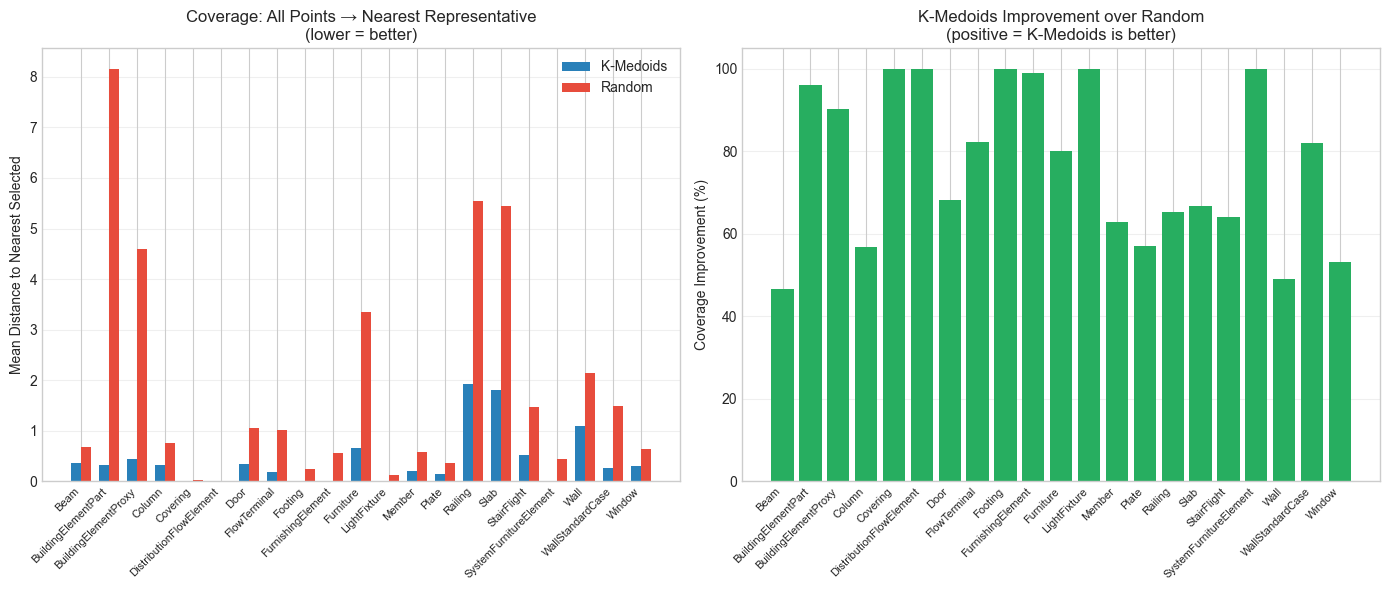

In [43]:
# Visualize K-Medoids vs Random
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(comp_df))
width = 0.35

# Coverage: avg dist from all points to nearest selected (lower = better)
ax = axes[0]
ax.bar(x - width/2, comp_df['km_coverage'], width, label='K-Medoids', color='#2980b9')
ax.bar(x + width/2, comp_df['rand_coverage'], width, label='Random', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('Ifc', '') for t in comp_df['ifc_type']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Distance to Nearest Selected')
ax.set_title('Coverage: All Points → Nearest Representative\n(lower = better)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Improvement percentage
ax = axes[1]
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in comp_df['coverage_improvement']]
ax.bar(x, comp_df['coverage_improvement'], color=colors)
ax.set_xticks(x)
ax.set_xticklabels([t.replace('Ifc', '') for t in comp_df['ifc_type']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coverage Improvement (%)')
ax.set_title('K-Medoids Improvement over Random\n(positive = K-Medoids is better)', fontsize=12)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. UMAP Visualization

In [44]:
from umap import UMAP

# Compute UMAP on full dataset
print("Computing UMAP (this may take a minute)...")
reducer = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
embedding = reducer.fit_transform(X_scaled)
print(f"UMAP done: {embedding.shape}")

Computing UMAP (this may take a minute)...
UMAP done: (128883, 2)


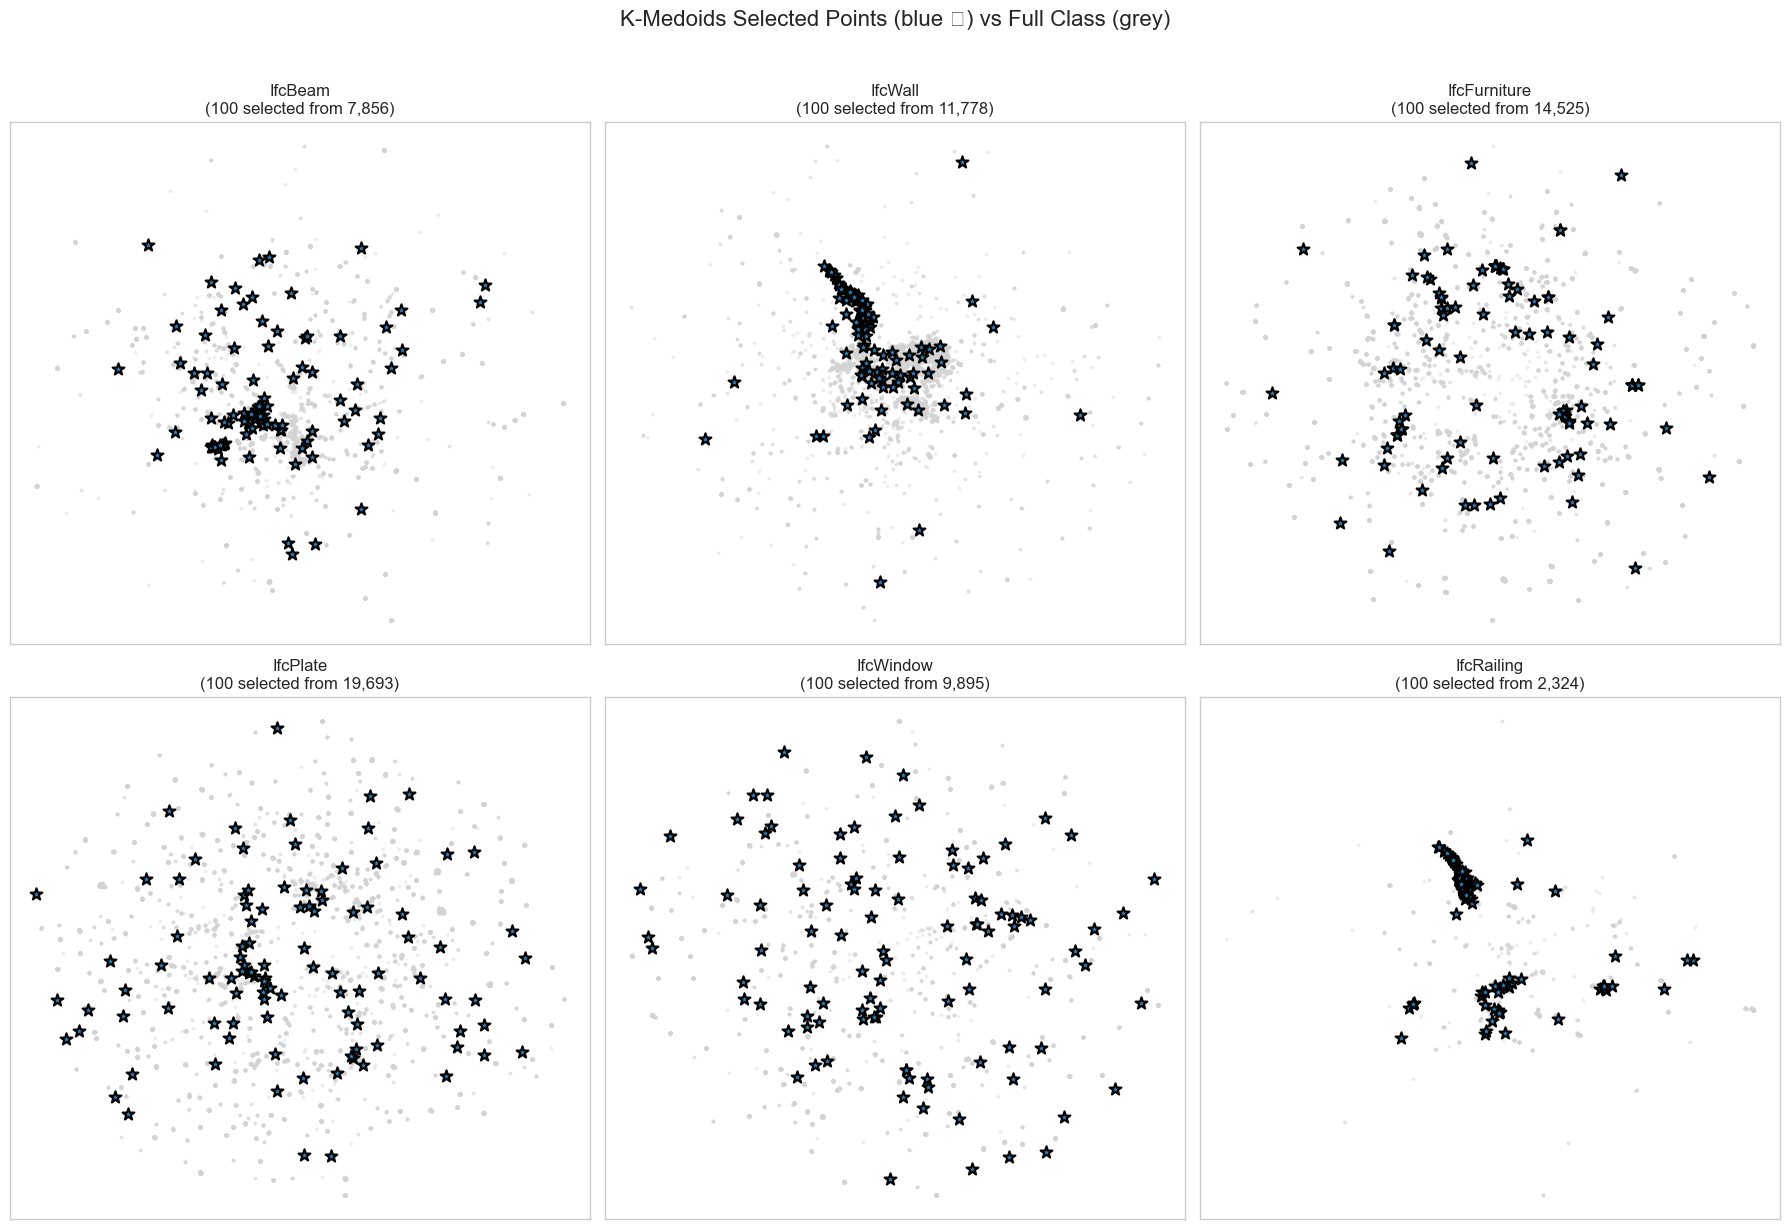

In [45]:
# Plot: Full dataset (grey) with K-Medoids selected points highlighted
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Pick 6 IFC types to visualize (mix of large and small)
viz_types = ['IfcBeam', 'IfcWall', 'IfcFurniture', 'IfcPlate', 'IfcWindow', 'IfcRailing']

for ax, ifc_type in zip(axes, viz_types):
    # All points of this type
    type_mask = df['IfcType'] == ifc_type
    type_emb = embedding[type_mask]
    
    # Find selected indices in full dataset
    sel_in_full = np.isin(df.index, df.index[selected_indices]) & type_mask
    sel_emb = embedding[sel_in_full]
    
    n_total = type_mask.sum()
    n_sel = sel_in_full.sum()
    
    # Plot all points (grey)
    ax.scatter(type_emb[:, 0], type_emb[:, 1], c='lightgrey', s=3, alpha=0.3)
    # Plot selected points (blue)
    ax.scatter(sel_emb[:, 0], sel_emb[:, 1], c='#2980b9', s=80, edgecolors='black', 
               linewidths=1.5, zorder=5, marker='*')
    
    ax.set_title(f'{ifc_type}\n({n_sel} selected from {n_total:,})', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('K-Medoids Selected Points (blue ★) vs Full Class (grey)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

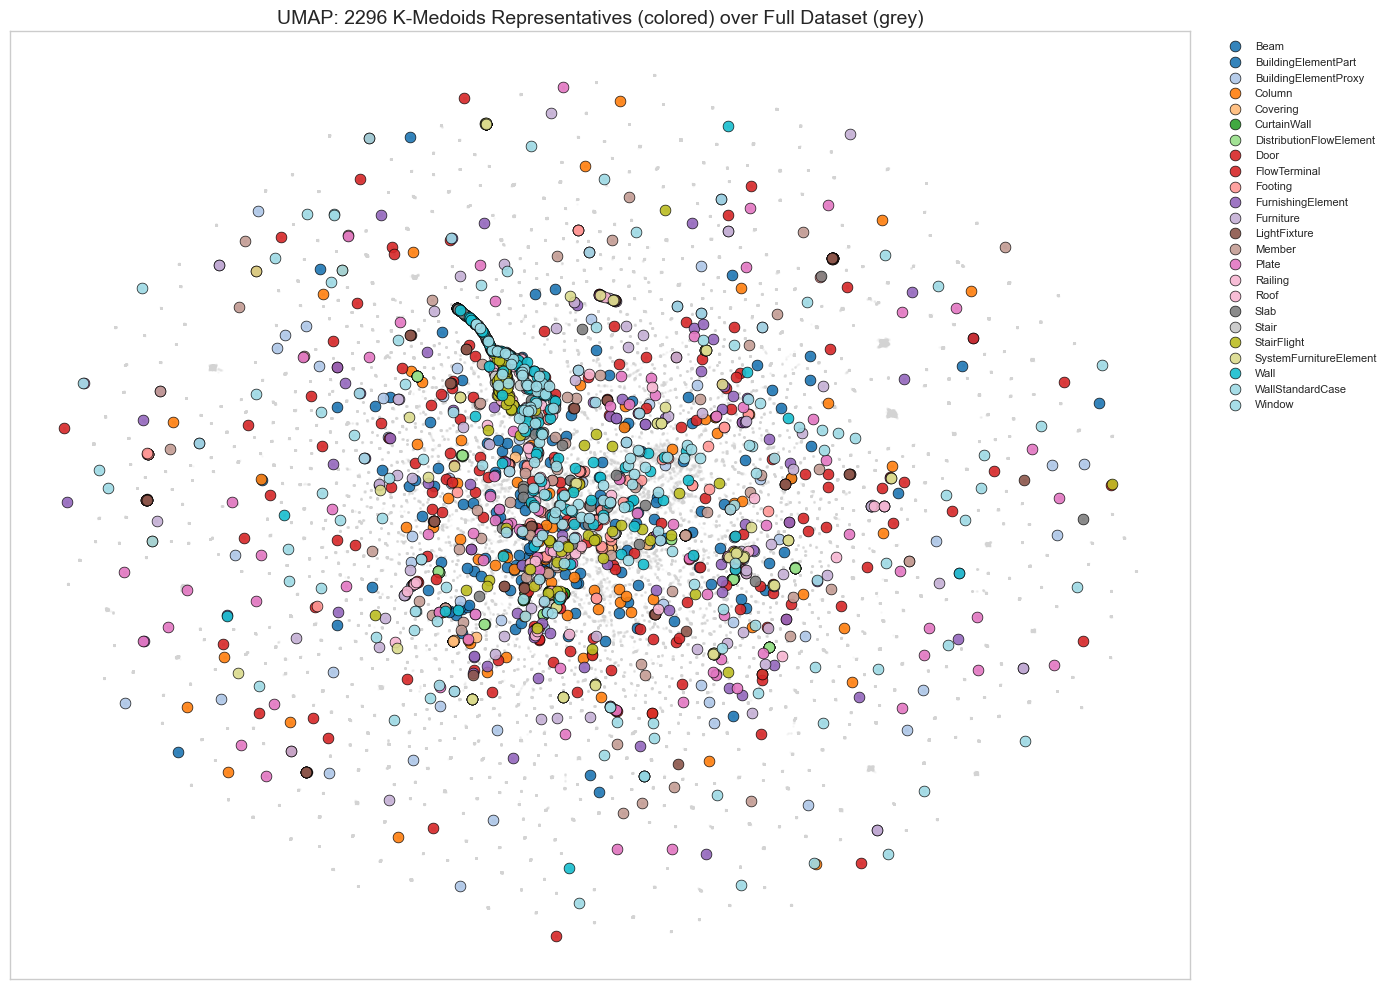

In [46]:
# Full UMAP: all types, selected highlighted
fig, ax = plt.subplots(figsize=(14, 10))

# All points (grey)
ax.scatter(embedding[:, 0], embedding[:, 1], c='lightgrey', s=1, alpha=0.1)

# Selected points colored by IFC type
sel_embedding = embedding[selected_indices]
ifc_types_sel = df.iloc[selected_indices]['IfcType'].values

unique_types = sorted(set(ifc_types_sel))
cmap = plt.cm.tab20(np.linspace(0, 1, len(unique_types)))
color_map = {t: cmap[i] for i, t in enumerate(unique_types)}

for ifc_type in unique_types:
    mask = ifc_types_sel == ifc_type
    ax.scatter(sel_embedding[mask, 0], sel_embedding[mask, 1],
               c=[color_map[ifc_type]], s=60, edgecolors='black',
               linewidths=0.5, label=ifc_type.replace('Ifc', ''), alpha=0.9)

ax.set_title(f'UMAP: {len(selected_indices)} K-Medoids Representatives (colored) over Full Dataset (grey)', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. Feature Distribution Check

Verify that selected points cover the full feature range of each class.

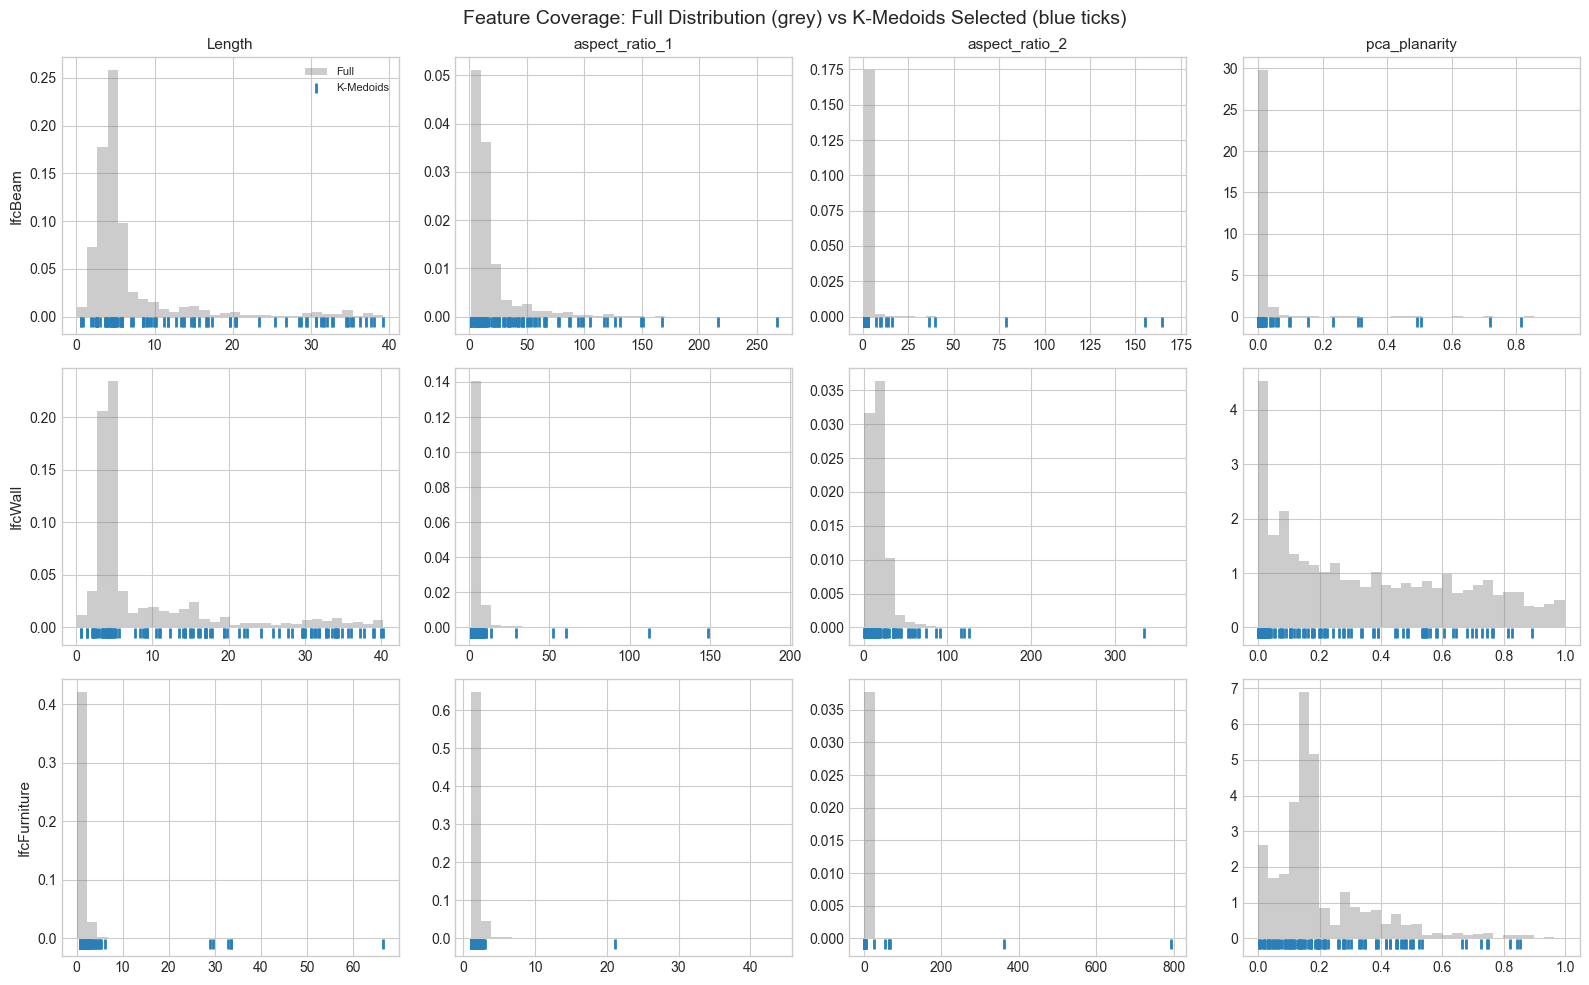

In [47]:
# For a few IFC types, compare feature distributions
check_types = ['IfcBeam', 'IfcWall', 'IfcFurniture']
check_features = ['Length', 'aspect_ratio_1', 'aspect_ratio_2', 'pca_planarity']

fig, axes = plt.subplots(len(check_types), len(check_features), figsize=(16, 10))

for i, ifc_type in enumerate(check_types):
    # Full class
    full_mask = df['IfcType'] == ifc_type
    full_data = df[full_mask]
    
    # Selected
    sel_data = df_selected[df_selected['IfcType'] == ifc_type]
    
    for j, feat in enumerate(check_features):
        ax = axes[i, j]
        
        # Full distribution
        ax.hist(full_data[feat], bins=30, alpha=0.4, color='grey', density=True, label='Full')
        
        # Selected points as rug plot
        sel_vals = sel_data[feat].values
        y_rug = -0.02 * ax.get_ylim()[1]
        ax.scatter(sel_vals, np.full_like(sel_vals, y_rug),
                   c='#2980b9', s=50, marker='|', linewidths=2, zorder=5, label='K-Medoids')
        
        if i == 0:
            ax.set_title(feat, fontsize=11)
        if j == 0:
            ax.set_ylabel(ifc_type, fontsize=11)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle('Feature Coverage: Full Distribution (grey) vs K-Medoids Selected (blue ticks)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Clustering Quality: Subset vs Full Dataset

Does the representative subset preserve clustering structure?  
Run BisectingKMeans (k=24) on both and compare Davies-Bouldin, Silhouette, and Purity.

In [48]:
from sklearn.cluster import BisectingKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

K_FIXED = 24  # Match number of IFC types

BASELINE_COLS = ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']

ENHANCED_COLS = [
    'aspect_ratio_1', 'aspect_ratio_2',
    'pca_planarity', 'face_area_cv', 'hull_vertex_ratio'
]

feature_sets = {
    'Baseline (4)': BASELINE_COLS,
    'Selection Features (9)': FEATURE_COLS,
    'Baseline+Enhanced (17)': BASELINE_COLS + [
        'aspect_ratio_1', 'aspect_ratio_2', 'aspect_ratio_3',
        'elongation', 'flatness', 'linearity', 'planarity', 'volumetricity',
        'pca_linearity', 'pca_planarity', 'pca_scattering',
        'face_area_cv', 'hull_vertex_ratio'
    ],
}

def compute_purity(labels, ifc_types):
    total = 0
    for cid in np.unique(labels):
        cluster_types = ifc_types[labels == cid]
        total += pd.Series(cluster_types).value_counts().iloc[0]
    return total / len(labels)

results = []

for feat_name, feat_cols in feature_sets.items():
    for data_label, data_df in [('Full (128k)', df), ('Subset (480)', df_selected)]:
        X = RobustScaler().fit_transform(data_df[feat_cols].values)
        ifc = data_df['IfcType'].values
        
        model = BisectingKMeans(
            n_clusters=K_FIXED,
            bisecting_strategy='largest_cluster',
            random_state=42
        )
        labels = model.fit_predict(X)
        
        results.append({
            'Features': feat_name,
            'Dataset': data_label,
            'Silhouette': silhouette_score(X, labels),
            'Davies-Bouldin': davies_bouldin_score(X, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X, labels),
            'Purity': compute_purity(labels, ifc),
        })

df_cmp = pd.DataFrame(results)

print(f"BisectingKMeans at k={K_FIXED}: Subset vs Full Dataset")
print("=" * 95)
print(f"\n{'Features':<25} {'Dataset':<16} {'DB (↓)':<10} {'Silhouette (↑)':<16} {'Purity (↑)':<12} {'CH (↑)':<12}")
print("-" * 95)
for _, r in df_cmp.iterrows():
    print(f"{r['Features']:<25} {r['Dataset']:<16} {r['Davies-Bouldin']:<10.4f} {r['Silhouette']:<16.4f} {r['Purity']:<12.4f} {r['Calinski-Harabasz']:<12.1f}")

KeyboardInterrupt: 

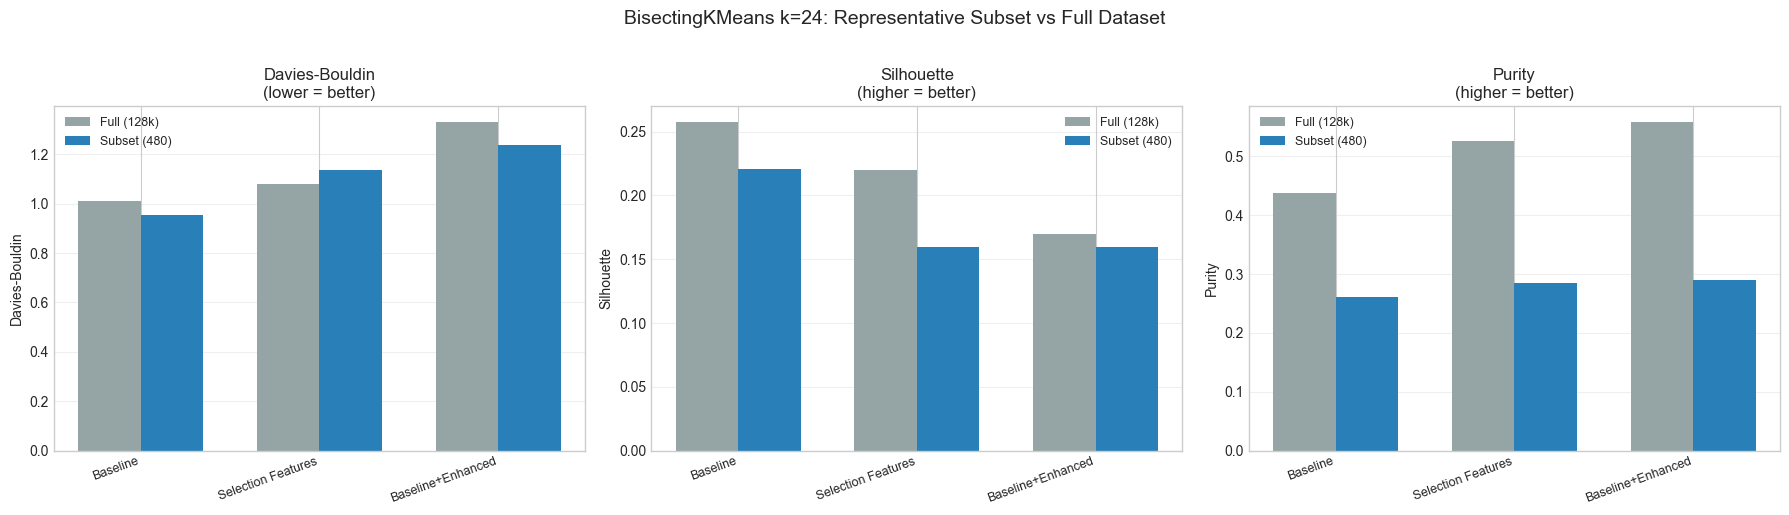

In [ ]:
# Grouped bar chart: Subset vs Full for each metric
metrics = ['Davies-Bouldin', 'Silhouette', 'Purity']
metric_dirs = ['lower', 'higher', 'higher']  # Direction of "better"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, direction in zip(axes, metrics, metric_dirs):
    feat_names = df_cmp['Features'].unique()
    x = np.arange(len(feat_names))
    width = 0.35
    
    full_vals = df_cmp[df_cmp['Dataset'] == 'Full (128k)'][metric].values
    sub_vals = df_cmp[df_cmp['Dataset'] == 'Subset (480)'][metric].values
    
    ax.bar(x - width/2, full_vals, width, label='Full (128k)', color='#95a5a6')
    ax.bar(x + width/2, sub_vals, width, label='Subset (480)', color='#2980b9')
    
    ax.set_xticks(x)
    ax.set_xticklabels([n.split(' (')[0] for n in feat_names], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}\n({direction} = better)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'BisectingKMeans k={K_FIXED}: Representative Subset vs Full Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

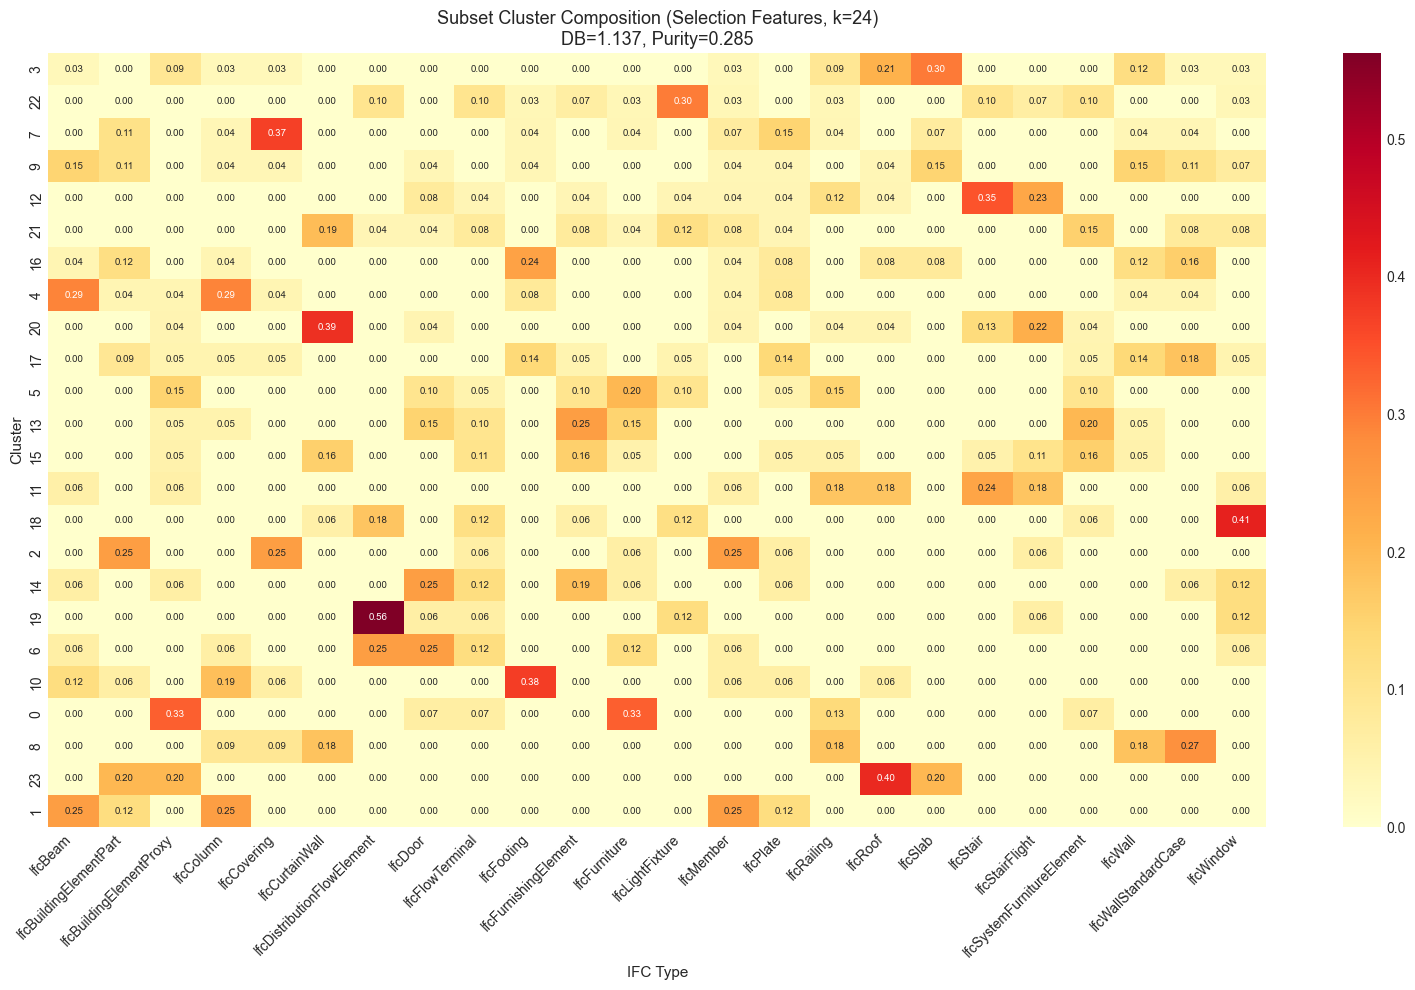


Cluster Details (top 10 by size):
Cluster    Size     Dominant Type                  Purity  
------------------------------------------------------------
3          33       IfcSlab                        0.303   
22         30       IfcLightFixture                0.300   
7          27       IfcCovering                    0.370   
9          27       IfcBeam                        0.148   
12         26       IfcStair                       0.346   
21         26       IfcCurtainWall                 0.192   
16         25       IfcFooting                     0.240   
4          24       IfcBeam                        0.292   
20         23       IfcCurtainWall                 0.391   
17         22       IfcWallStandardCase            0.182   


In [ ]:
# Cluster composition heatmap: Subset with Selection Features
X_sub = RobustScaler().fit_transform(df_selected[FEATURE_COLS].values)
model_sub = BisectingKMeans(n_clusters=K_FIXED, bisecting_strategy='largest_cluster', random_state=42)
sub_labels = model_sub.fit_predict(X_sub)

ct = pd.crosstab(
    pd.Series(sub_labels, name='Cluster'),
    pd.Series(df_selected['IfcType'].values, name='IFC Type'),
    normalize='index'
)
# Sort clusters by size
cluster_order = pd.Series(sub_labels).value_counts().index
ct = ct.reindex(cluster_order)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 7})
ax.set_title(f'Subset Cluster Composition (Selection Features, k={K_FIXED})\n'
             f'DB={df_cmp[(df_cmp["Features"]=="Selection Features (9)") & (df_cmp["Dataset"]=="Subset (480)")]["Davies-Bouldin"].values[0]:.3f}, '
             f'Purity={df_cmp[(df_cmp["Features"]=="Selection Features (9)") & (df_cmp["Dataset"]=="Subset (480)")]["Purity"].values[0]:.3f}',
             fontsize=13)
ax.set_xlabel('IFC Type', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print cluster purity details
print(f"\nCluster Details (top 10 by size):")
print(f"{'Cluster':<10} {'Size':<8} {'Dominant Type':<30} {'Purity':<8}")
print("-" * 60)
ifc_arr = df_selected['IfcType'].values
for cid in cluster_order[:10]:
    mask = sub_labels == cid
    types = ifc_arr[mask]
    vc = pd.Series(types).value_counts()
    print(f"{cid:<10} {mask.sum():<8} {vc.index[0]:<30} {vc.iloc[0]/mask.sum():<8.3f}")

## 8. Export Selected Subset

In [49]:
# Export
output_dir = Path('../../processed_data/subsets')
output_dir.mkdir(parents=True, exist_ok=True)

# Save with all metadata
export_cols = ['GlobalId', 'IfcType'] if 'GlobalId' in df_selected.columns else ['IfcType']
export_cols += [c for c in FEATURE_COLS if c in df_selected.columns]
if 'mesh_filename' in df_selected.columns:
    export_cols.insert(2, 'mesh_filename')

output_path = output_dir / f'representative_subset_{X_PER_CLASS}per_class.csv'
df_selected[export_cols].to_csv(output_path, index=False)
print(f"Exported {len(df_selected)} objects to:")
print(f"  {output_path}")

# Also save mesh filenames for viewer
if 'mesh_filename' in df_selected.columns:
    mesh_list_path = output_dir / f'representative_subset_{X_PER_CLASS}per_class_meshes.txt'
    with open(mesh_list_path, 'w') as f:
        for _, row in df_selected.iterrows():
            f.write(f"{row['mesh_filename']}\n")
    print(f"  {mesh_list_path}")

Exported 2296 objects to:
  ../../processed_data/subsets/representative_subset_100per_class.csv


In [50]:
import json

# Export filtered metadata.json for the selected subset
metadata_path = Path('../../data/metadata.json')
with open(metadata_path) as f:
    all_metadata = json.load(f)

selected_gids = set(df_selected['GlobalId'].values)
filtered_metadata = [m for m in all_metadata if m['GlobalId'] in selected_gids]

subset_metadata_path = output_dir / 'metadata.json'
with open(subset_metadata_path, 'w') as f:
    json.dump(filtered_metadata, f, indent=2)

print(f"Filtered metadata: {len(filtered_metadata)} / {len(all_metadata)} entries")
print(f"  → {subset_metadata_path}")

Filtered metadata: 2303 / 247880 entries
  → ../../processed_data/subsets/metadata.json


In [51]:
import shutil

# Copy mesh OBJ files for selected subset
meshes_src = Path('../../processed_data/meshes/train')
meshes_dst = output_dir / 'meshes'
meshes_dst.mkdir(parents=True, exist_ok=True)

copied = 0
missing = 0
for gid in df_selected['GlobalId'].values:
    src = meshes_src / f'{gid}.obj'
    if src.exists():
        shutil.copy2(src, meshes_dst / f'{gid}.obj')
        copied += 1
    else:
        missing += 1

print(f"Copied {copied} mesh files to {meshes_dst}")
if missing > 0:
    print(f"  WARNING: {missing} mesh files not found in {meshes_src}")

Copied 2296 mesh files to ../../processed_data/subsets/meshes


In [ ]:
# Summary
print("\n" + "=" * 60)
print("SELECTION SUMMARY")
print("=" * 60)
print(f"\nMethod: K-Medoids (KMeans + nearest-to-centroid)")
print(f"Features: {len(FEATURE_COLS)} geometric features (RobustScaler)")
print(f"X per class: {X_PER_CLASS}")
print(f"Total selected: {len(df_selected)}")
print(f"\nRepresentativeness advantage over random:")
print(f"  Median coverage improvement: {comp_df['coverage_improvement'].median():.1f}%")

print(f"\nClustering comparison (BisectingKMeans k={K_FIXED}):")
for feat_name in df_cmp['Features'].unique():
    full_row = df_cmp[(df_cmp['Features'] == feat_name) & (df_cmp['Dataset'] == 'Full (128k)')].iloc[0]
    sub_row = df_cmp[(df_cmp['Features'] == feat_name) & (df_cmp['Dataset'] == 'Subset (480)')].iloc[0]
    print(f"\n  {feat_name}:")
    print(f"    DB:     Full={full_row['Davies-Bouldin']:.3f}  Subset={sub_row['Davies-Bouldin']:.3f}")
    print(f"    Purity: Full={full_row['Purity']:.3f}  Subset={sub_row['Purity']:.3f}")

AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

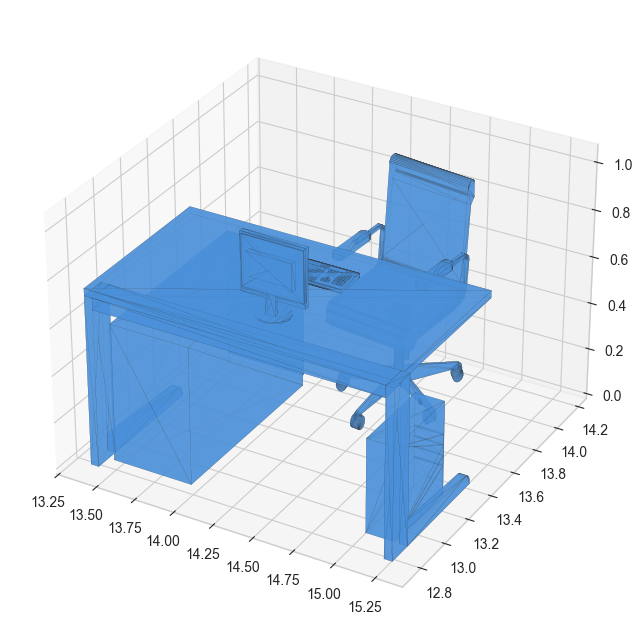

In [34]:
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

mesh = trimesh.load('/Users/sercanamac/Bentley3D/processed_data/meshes/train/2VCof_7vX6oAo04TF1Xqmu.obj', force='mesh')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

vertices = mesh.vertices
faces = mesh.faces
polygons = vertices[faces]

collection = Poly3DCollection(polygons, alpha=0.7, edgecolor='#333', linewidth=0.1)
collection.set_facecolor('#4a90d9')
ax.add_collection3d(collection)

# Auto-scale
scale = vertices.ptp(axis=0)
mid = vertices.mean(axis=0)
max_range = scale.max() / 2
ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

ax.set_title(f'2VCof_7vX6oAo04TF1Xqmu — IfcBeam\n'
             f'{len(vertices):,} vertices, {len(faces):,} faces', fontsize=13)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

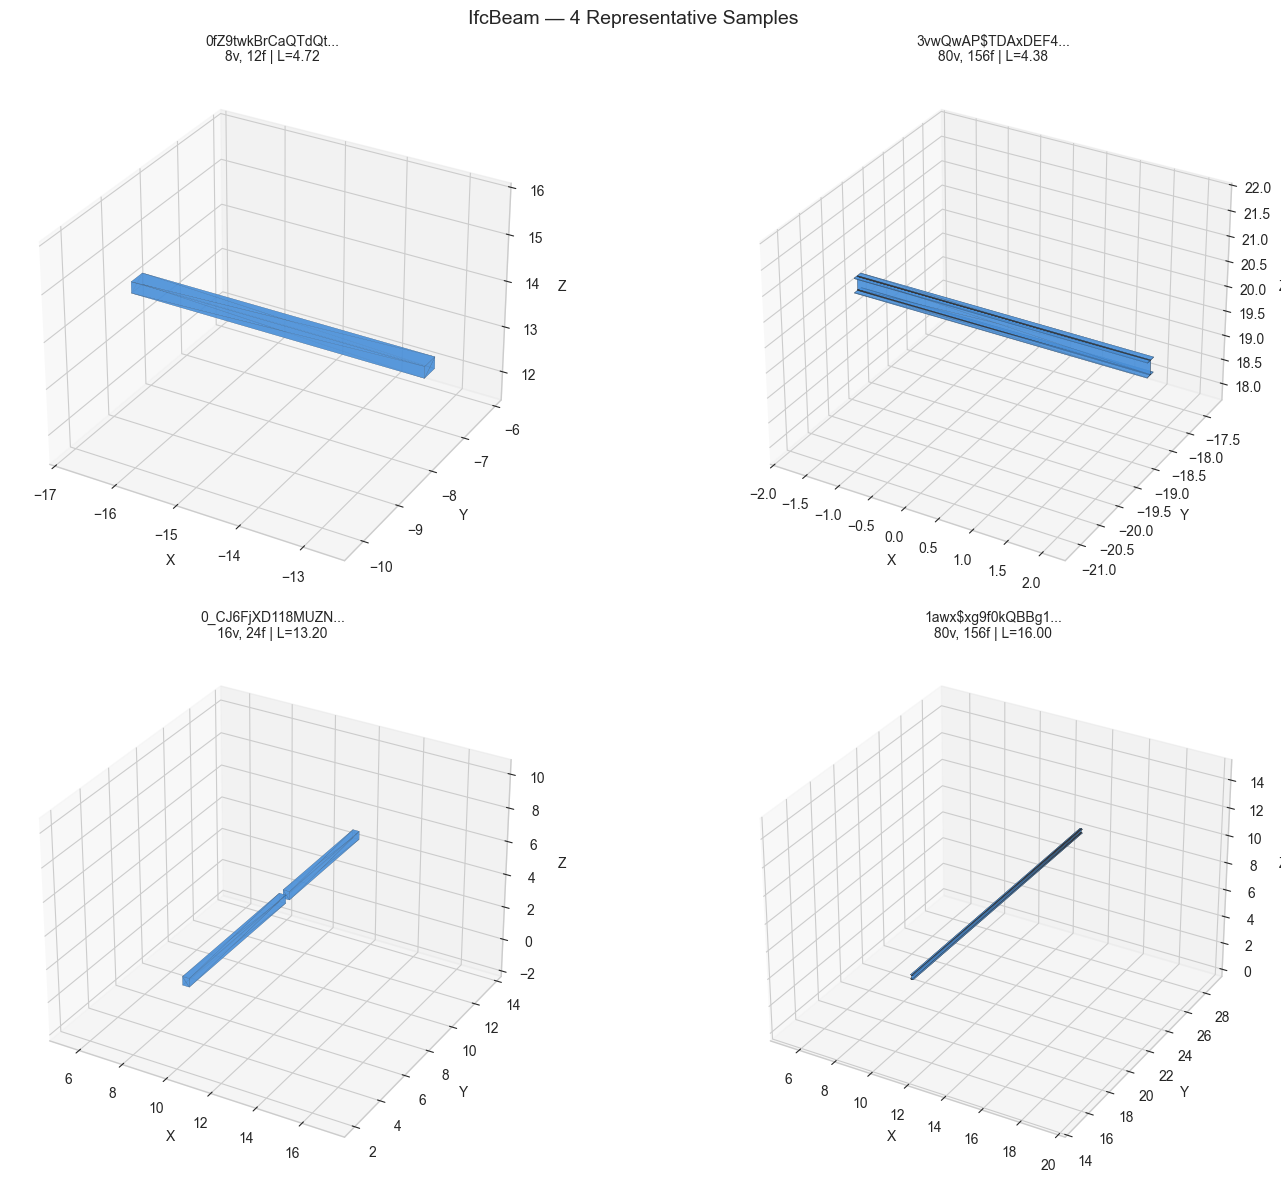

In [35]:
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import pandas as pd
from pathlib import Path

# Get all IfcBeam objects from the subset
beams = pd.read_csv('/Users/sercanamac/Bentley3D/processed_data/subsets/representative_subset_20per_class.csv')
beams = beams[beams['IfcType'] == 'IfcBeam']

# Pick 4 beams to show variety
indices = [0, 5, 10, 15]
fig = plt.figure(figsize=(16, 12))

for i, idx in enumerate(indices):
    gid = beams.iloc[idx]['GlobalId']
    mesh_path = f'/Users/sercanamac/Bentley3D/processed_data/meshes/train/{gid}.obj'
    mesh = trimesh.load(mesh_path, force='mesh')
    
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    vertices = mesh.vertices
    faces = mesh.faces
    polygons = vertices[faces]
    
    collection = Poly3DCollection(polygons, alpha=0.7, edgecolor='#333', linewidth=0.1)
    collection.set_facecolor('#4a90d9')
    ax.add_collection3d(collection)
    
    scale = np.ptp(vertices, axis=0)
    mid = vertices.mean(axis=0)
    max_range = scale.max() / 2
    ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax.set_zlim(mid[2] - max_range, mid[2] + max_range)
    
    ax.set_title(f'{gid[:16]}...\n{len(vertices):,}v, {len(faces):,}f | L={beams.iloc[idx]["Length"]:.2f}', fontsize=10)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')

plt.suptitle('IfcBeam — 4 Representative Samples', fontsize=14)
plt.tight_layout()
plt.show()